In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
# Importamos as funções e constantes do seu arquivo diabetes.py
from diabetes import (
    TRADUCAO_COLUNAS, EXP_PROFISSIONAL, EXP_ACADEMICO,
    separar_recursos_e_alvo, executar_experimentos,
    plotar_comparativo_metricas, plotar_importancia_variaveis,
    plotar_matriz_confusao, visualizar_arvore, plotar_comparativo_final,
    plotar_curva_roc, plotar_duelo_geral_ordenado, plotar_duelo_geral_destacado
)
from matplotlib.lines import Line2D


# Carga e Tradução automática
df_diabetes = pd.read_csv('diabetes.csv').rename(columns=TRADUCAO_COLUNAS)
X, y = separar_recursos_e_alvo(df_diabetes)

print("Dados carregados e traduzidos com sucesso!")
df_diabetes.head()


Dados carregados e traduzidos com sucesso!


,Gravidez,Glicose,Pressao,Pele,Insulina,IMC,Historico,Idade,Resultado
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


,Acurácia,Precisão,Recall,F1-Score,X_teste
Configuracao,,,,,
Gini / Prof. 3,0.776042,0.760000,0.550725,0.638655,Gravidez Glicose Pressao Pele Insulin...
Gini / Prof. 5,0.765625,0.693548,0.623188,0.656489,Gravidez Glicose Pressao Pele Insulin...
Entropia / Prof. 3,0.776042,0.760000,0.550725,0.638655,Gravidez Glicose Pressao Pele Insulin...
Entropia / Prof. 5,0.718750,0.627119,0.536232,0.578125,Gravidez Glicose Pressao Pele Insulin...


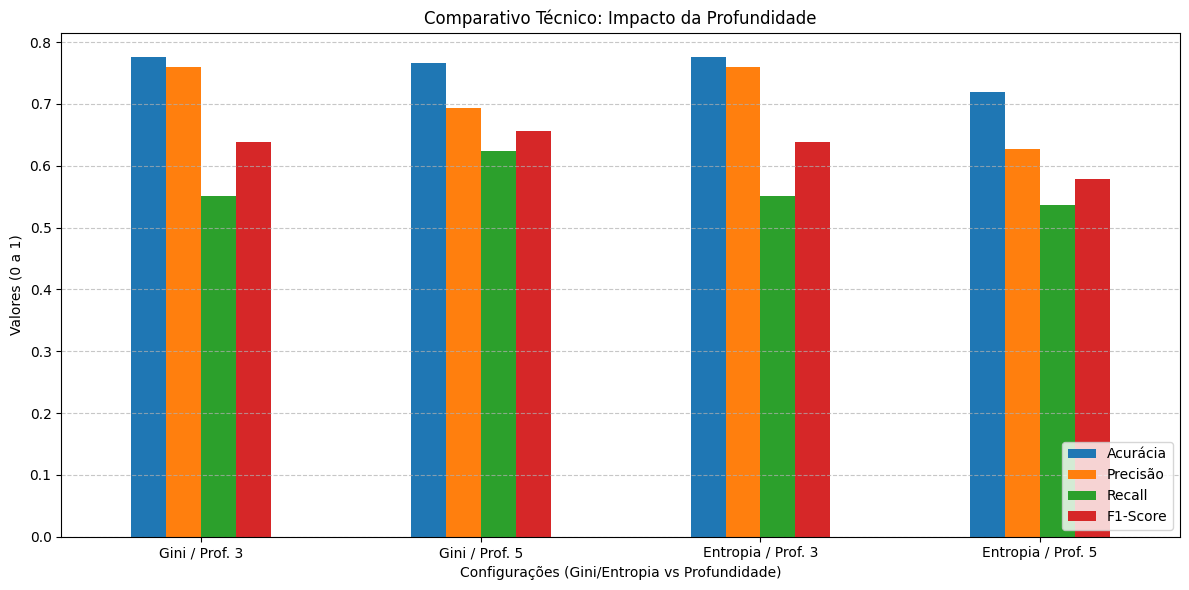

In [ ]:
# Executa o teste técnico focando em profundidade (max_depth)
df_res_prof = executar_experimentos(X, y, EXP_PROFISSIONAL, eh_profissional=True)
 
# Exibe a tabela e o gráfico comparativo
display(df_res_prof.drop(columns=['modelo', 'y_real', 'y_previsto']))
plotar_comparativo_metricas(df_res_prof, "Comparativo Técnico: Impacto da Profundidade", "Configurações (Gini/Entropia vs Profundidade)")


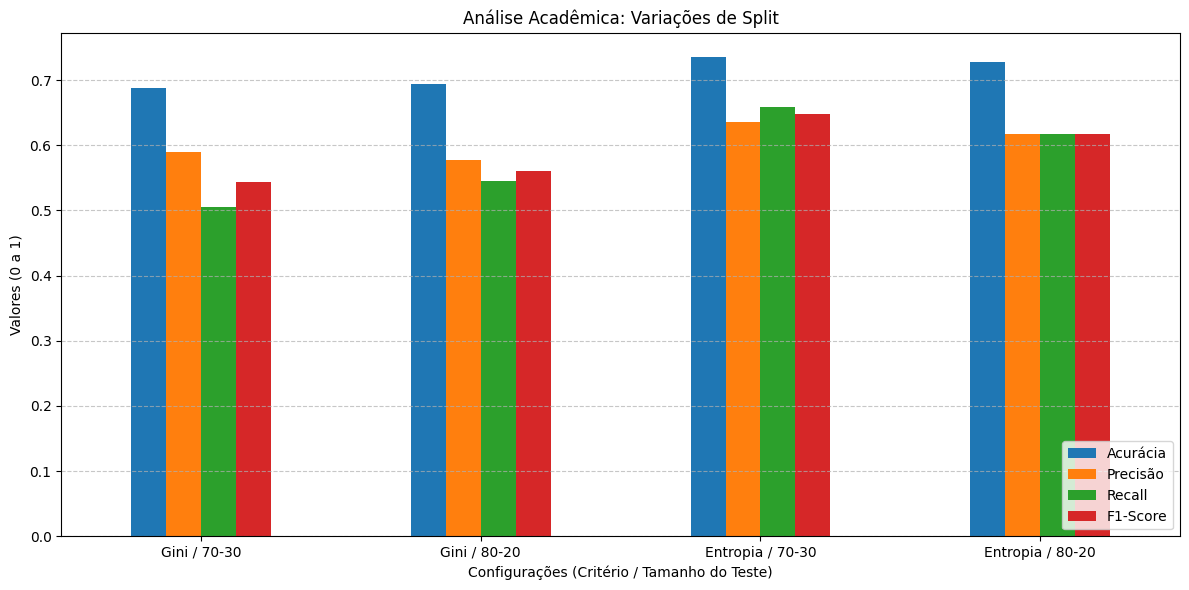

In [4]:
# Executa o teste acadêmico variando o tamanho do treino/teste
df_res_acad = executar_experimentos(X, y, EXP_ACADEMICO, eh_profissional=False)

# Exibe o gráfico comparativo
plotar_comparativo_metricas(df_res_acad, "Análise Acadêmica: Variações de Split", "Configurações (Critério / Tamanho do Teste)")


--- Detalhando o Modelo Profissional: Entropia / Prof. 5 ---


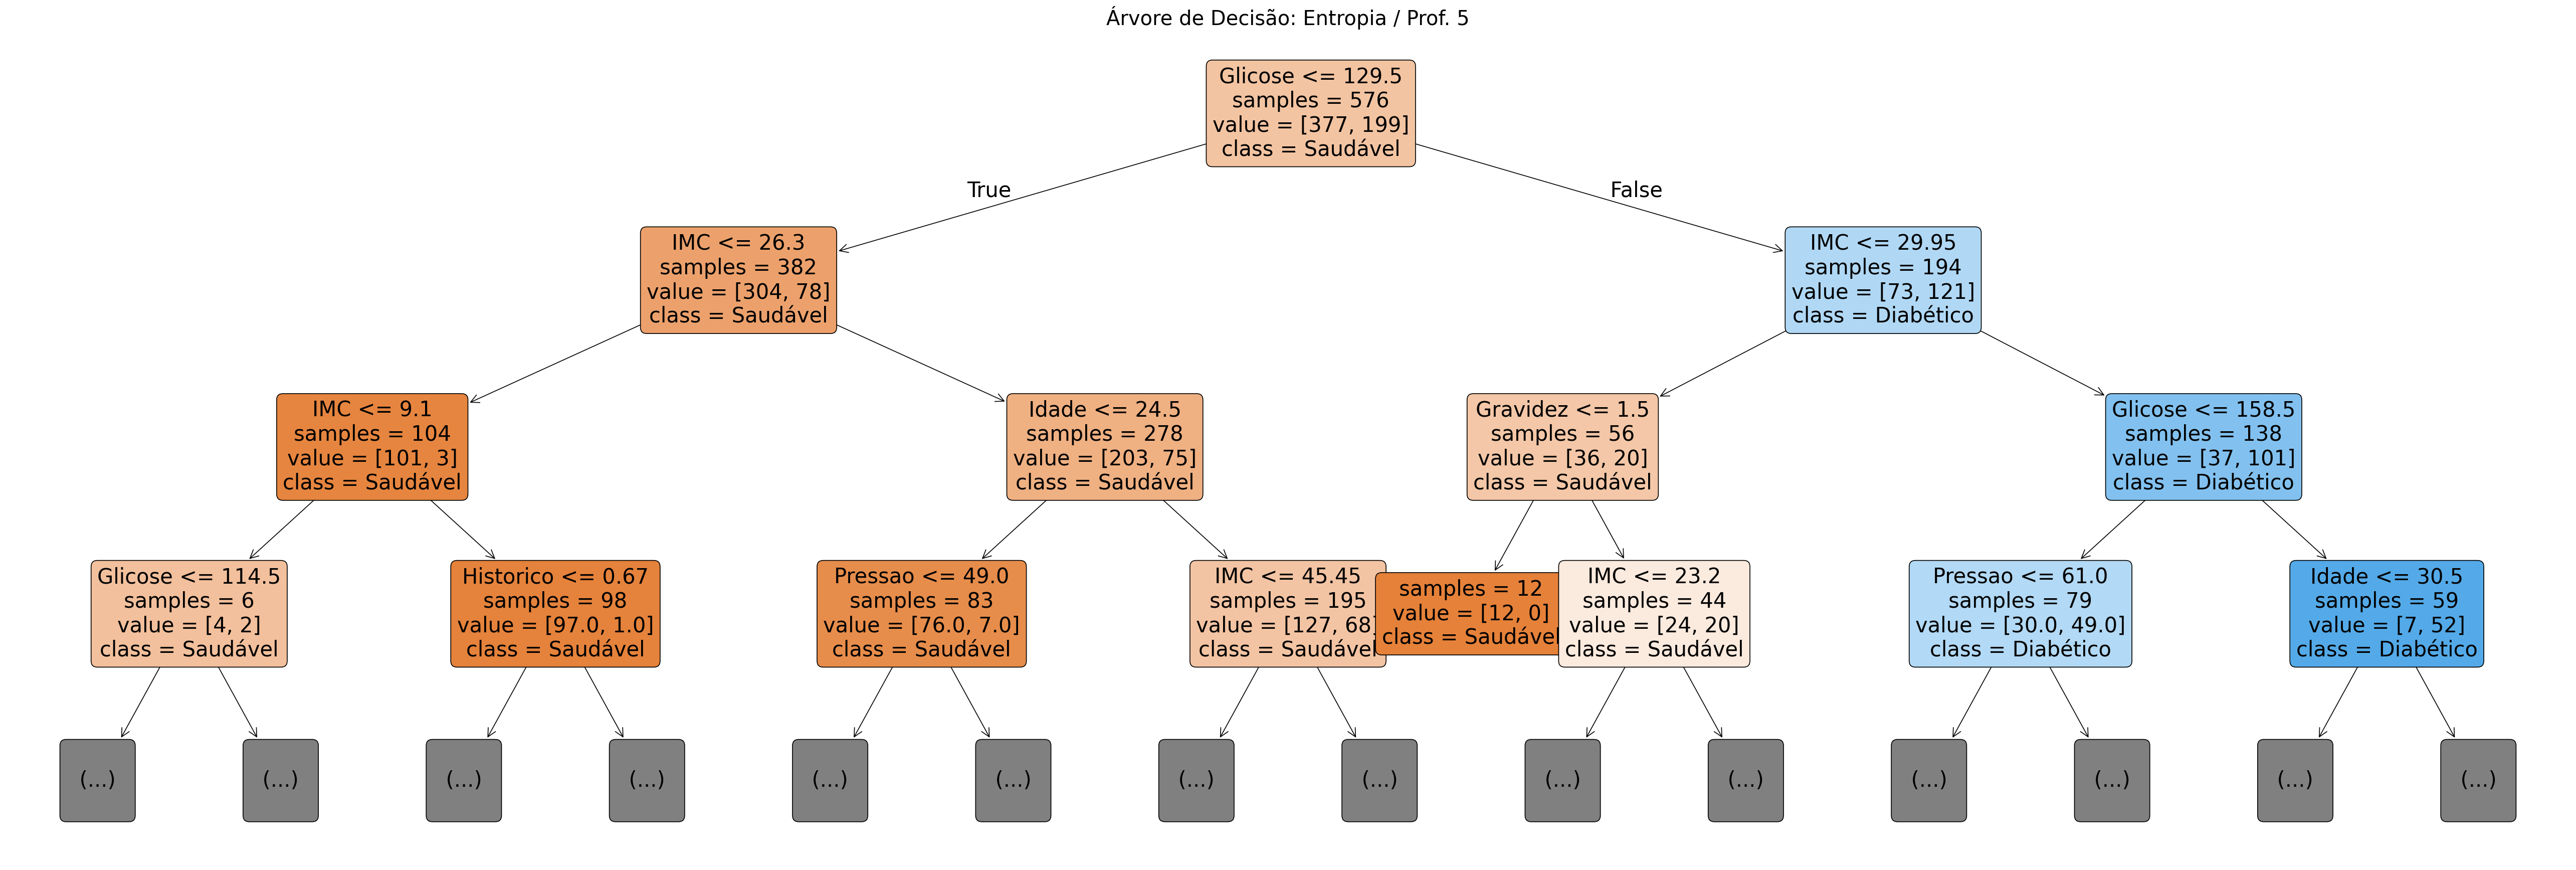

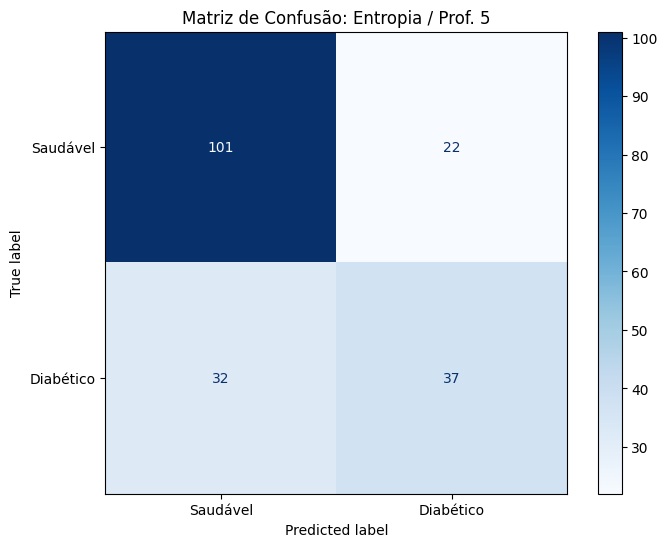

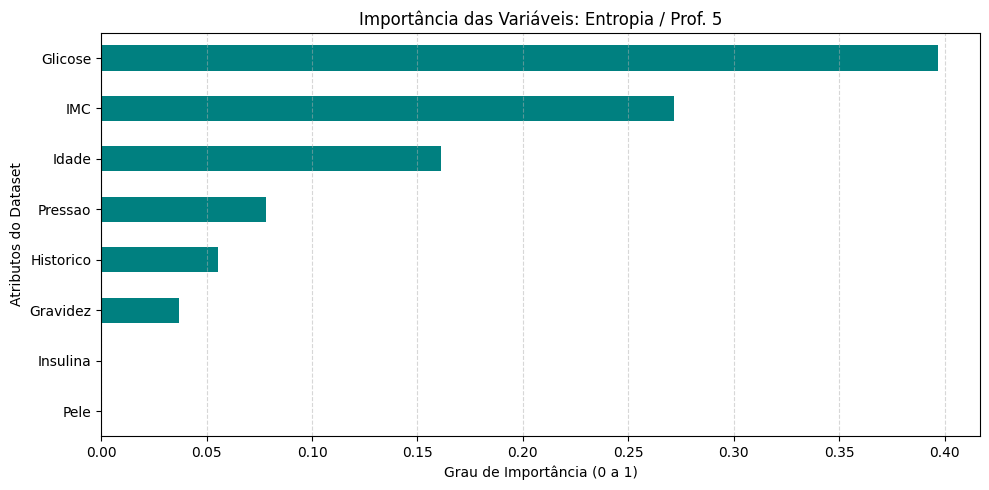

In [5]:
# Selecionamos o melhor modelo do teste profissional (última linha)
melhor_config_prof = df_res_prof.index[-1]
modelo_prof = df_res_prof.loc[melhor_config_prof, 'modelo']

print(f"--- Detalhando o Modelo Profissional: {melhor_config_prof} ---")

# 1. Visualização da Árvore
visualizar_arvore(modelo_prof, X.columns, melhor_config_prof)

# 2. Matriz de Confusão
plotar_matriz_confusao(
    df_res_prof.loc[melhor_config_prof, 'y_real'], 
    df_res_prof.loc[melhor_config_prof, 'y_previsto'], 
    melhor_config_prof
)

# 3. Importância das Variáveis
plotar_importancia_variaveis(modelo_prof, X.columns, melhor_config_prof)


--- Detalhando o Modelo Acadêmico: Entropia / 80-20 ---


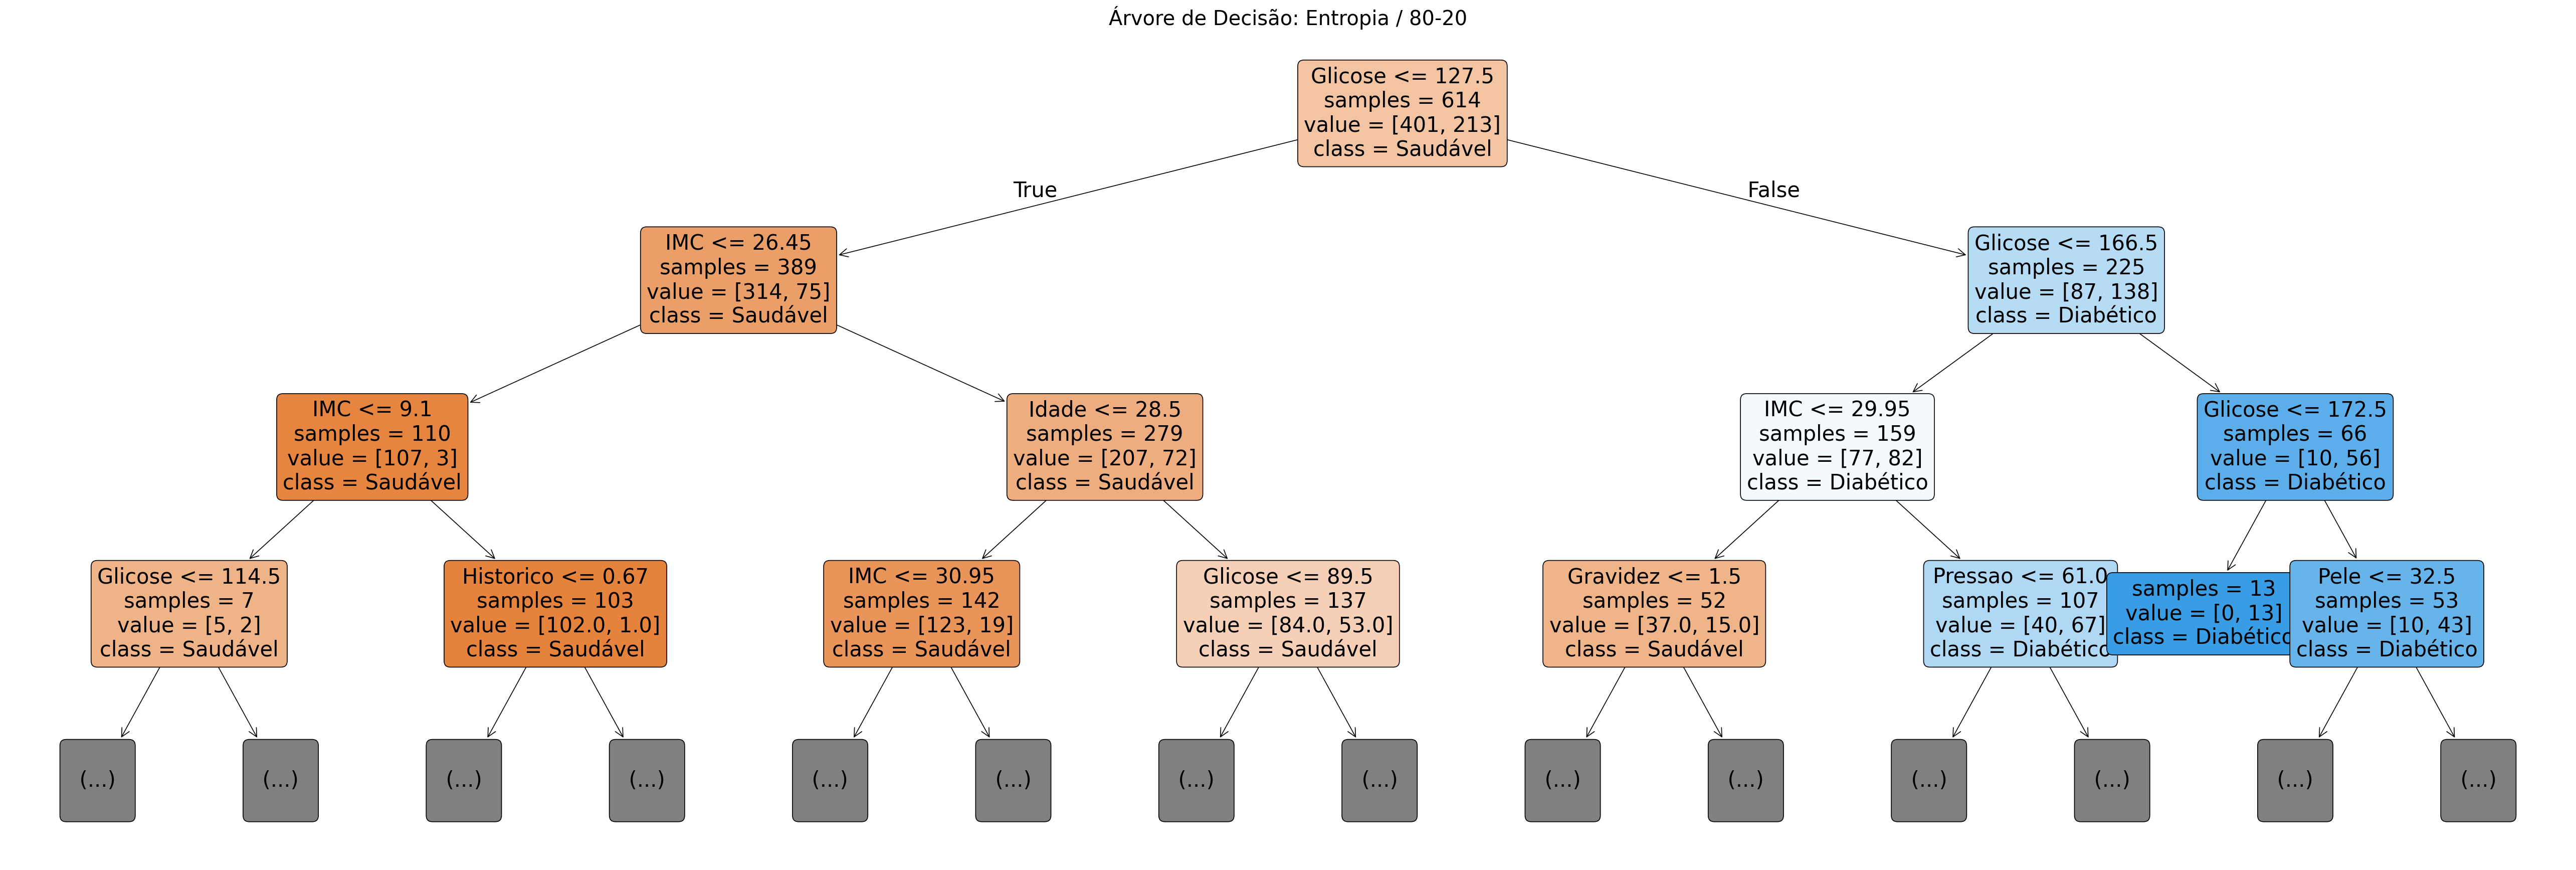

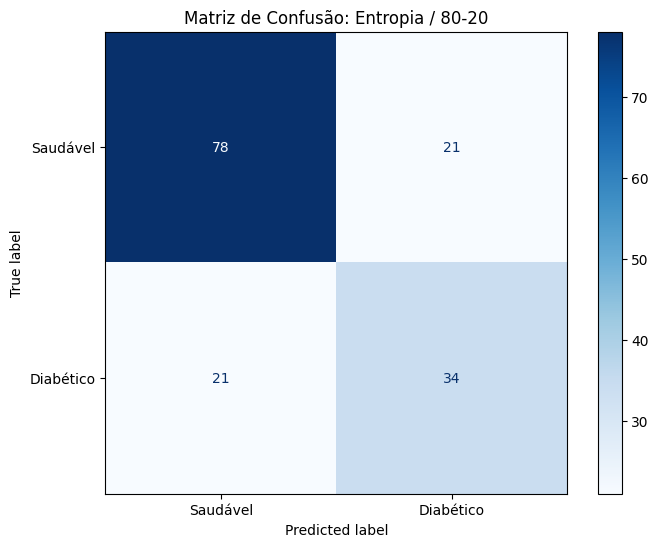

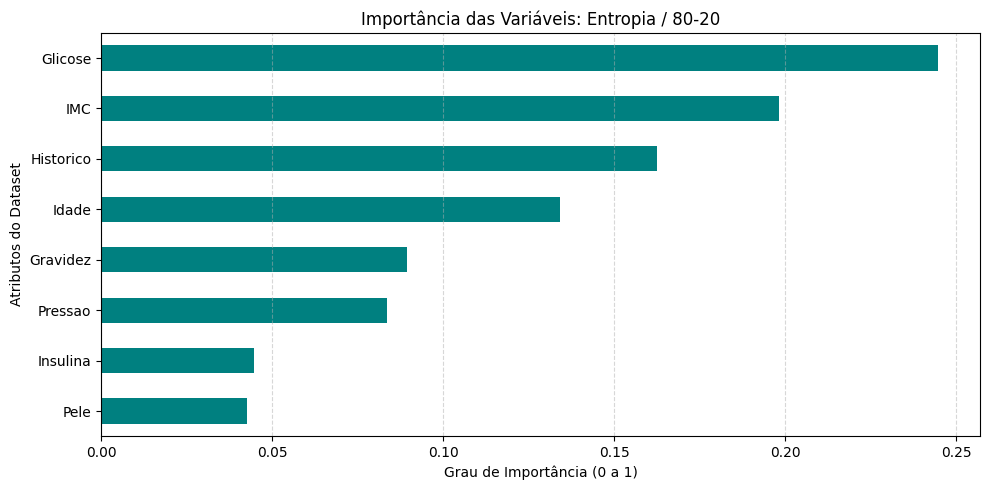

In [6]:
# Selecionamos o melhor modelo do teste acadêmico (última linha)
melhor_config_acad = df_res_acad.index[-1]
modelo_acad = df_res_acad.loc[melhor_config_acad, 'modelo']

print(f"--- Detalhando o Modelo Acadêmico: {melhor_config_acad} ---")

# 1. Visualização da Árvore (Note: esta pode ser maior pois depth é None)
visualizar_arvore(modelo_acad, X.columns, melhor_config_acad)

# 2. Matriz de Confusão
plotar_matriz_confusao(
    df_res_acad.loc[melhor_config_acad, 'y_real'], 
    df_res_acad.loc[melhor_config_acad, 'y_previsto'], 
    melhor_config_acad
)

# 3. Importância das Variáveis
plotar_importancia_variaveis(modelo_acad, X.columns, melhor_config_acad)


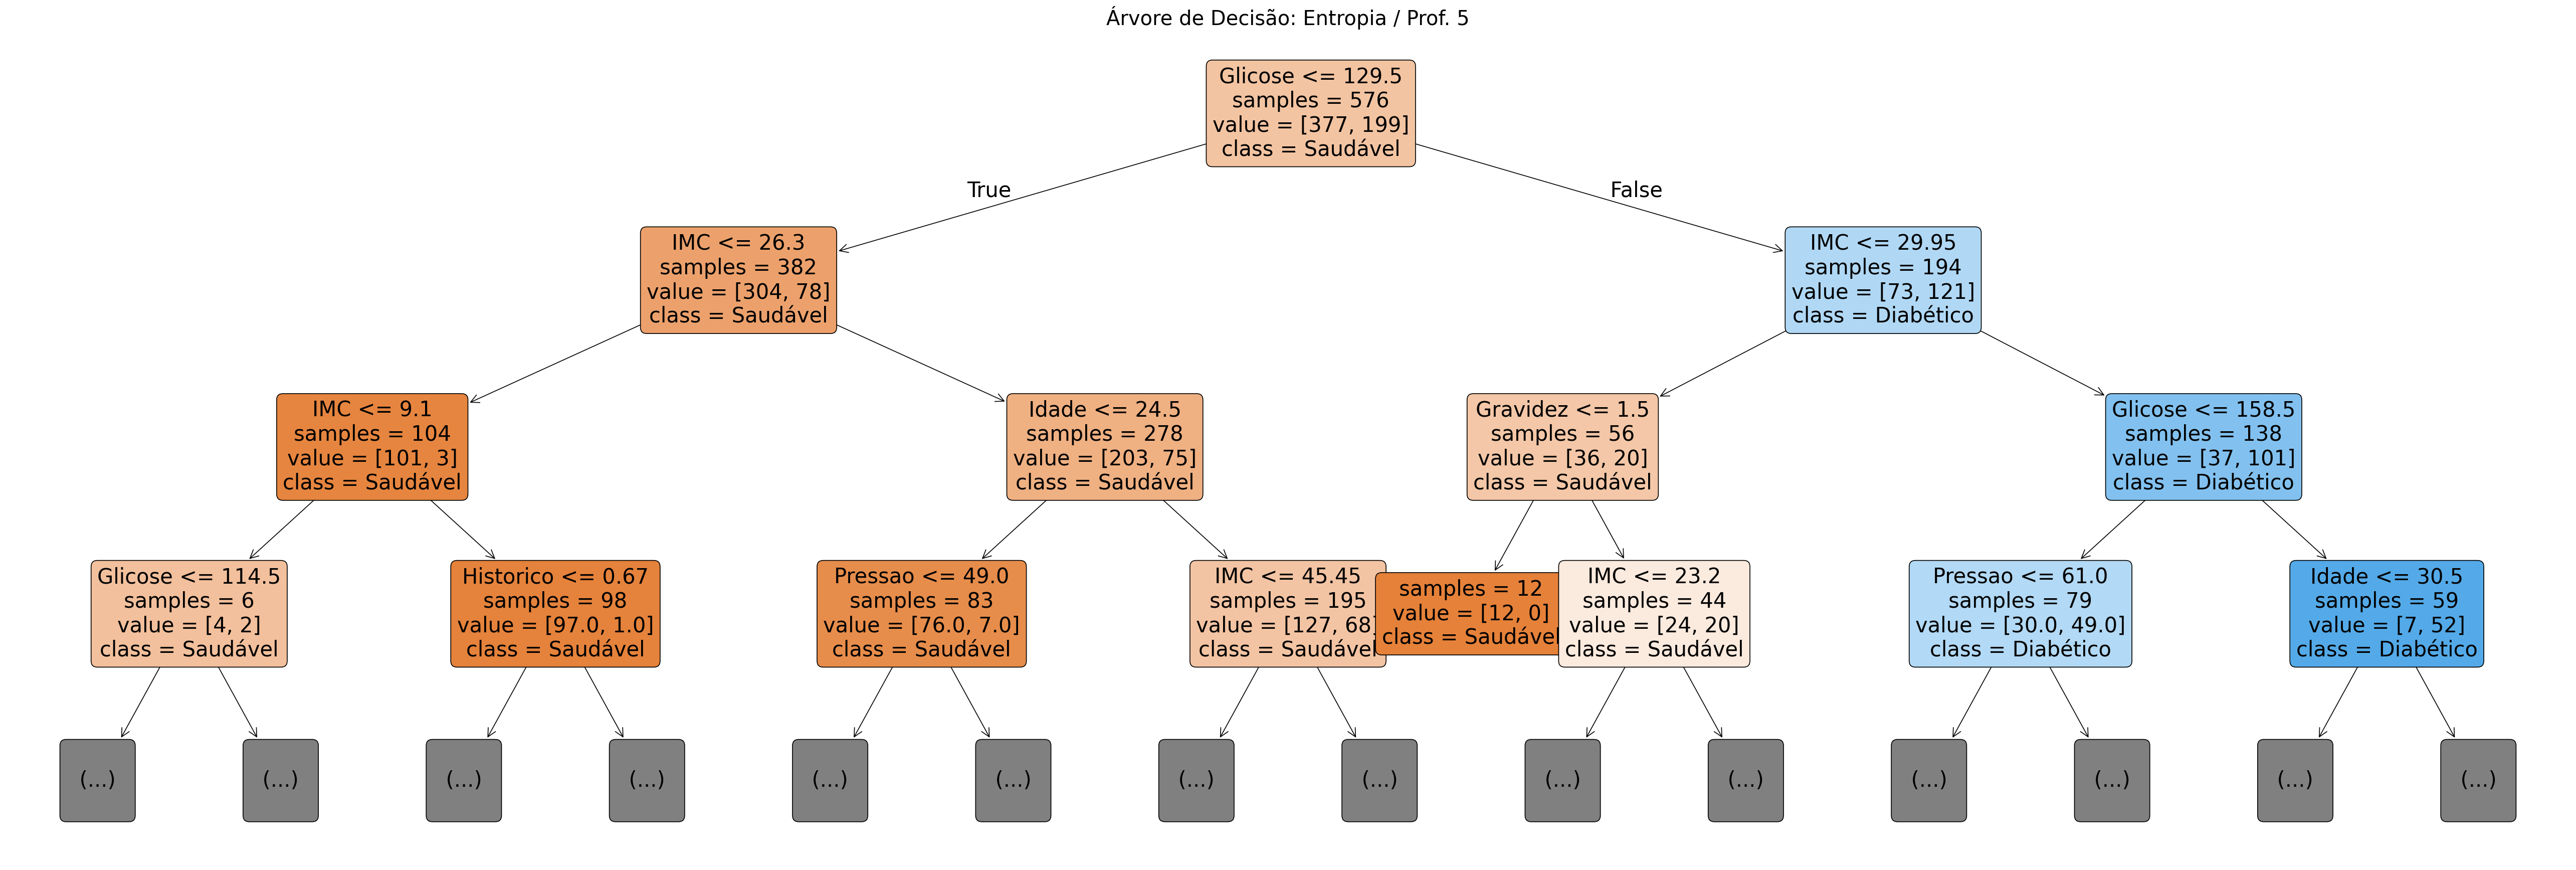

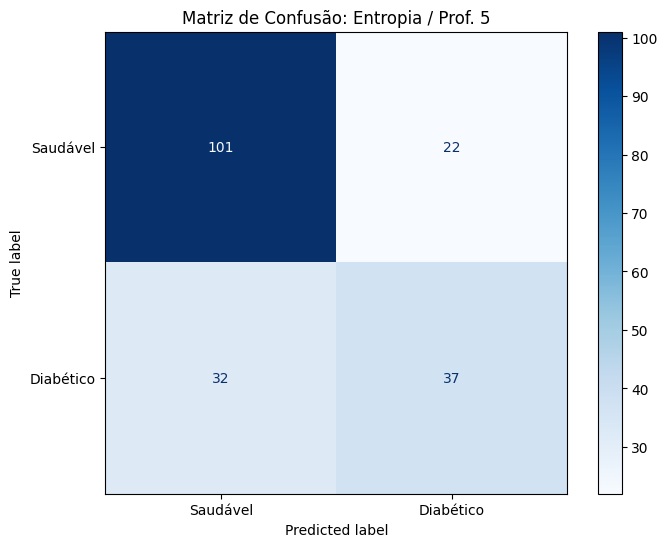

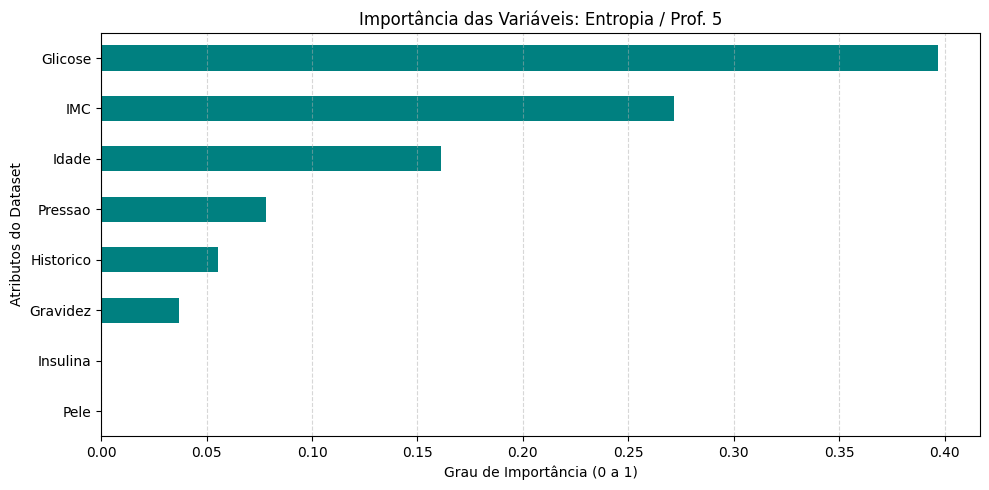

In [7]:
# Selecionamos o último modelo do teste profissional para detalhamento
melhor_config = df_res_prof.index[-1]
modelo_final = df_res_prof.loc[melhor_config, 'modelo']

# 1. Visualização da Árvore
visualizar_arvore(modelo_final, X.columns, melhor_config)

# 2. Matriz de Confusão
plotar_matriz_confusao(
    df_res_prof.loc[melhor_config, 'y_real'], 
    df_res_prof.loc[melhor_config, 'y_previsto'], 
    melhor_config
)

# 3. Importância das Variáveis
plotar_importancia_variaveis(modelo_final, X.columns, melhor_config)


In [8]:
# 1. Encontrar as melhores acurácias de cada experimento
melhor_prof = df_res_prof['Acurácia'].max()
melhor_acad = df_res_acad['Acurácia'].max()

print("--- RELATÓRIO DE DESEMPENHO ---")
print(f"Melhor Acurácia Profissional: {melhor_prof:.2%}")
print(f"Melhor Acurácia Acadêmica: {melhor_acad:.2%}")
print("-" * 30)

if melhor_prof >= melhor_acad:
    print("VENCEDOR: MODELO PROFISSIONAL")
    print("PORQUE: Ele conseguiu manter um desempenho alto mesmo sendo uma árvore simples (profundidade limitada).")
    print("Isso evita o 'Overfitting' (decorar os dados), tornando-o mais confiável para novos pacientes.")
else:
    print("VENCEDOR: MODELO ACADÊMICO")
    print("PORQUE: Ao não limitar a profundidade, a árvore explorou todas as combinações possíveis de dados.")
    print("Atenção: Embora a acurácia seja maior, esse modelo pode estar 'viciado' nos dados de treino.")


--- RELATÓRIO DE DESEMPENHO ---
Melhor Acurácia Profissional: 77.60%
Melhor Acurácia Acadêmica: 73.59%
------------------------------
VENCEDOR: MODELO PROFISSIONAL
PORQUE: Ele conseguiu manter um desempenho alto mesmo sendo uma árvore simples (profundidade limitada).
Isso evita o 'Overfitting' (decorar os dados), tornando-o mais confiável para novos pacientes.


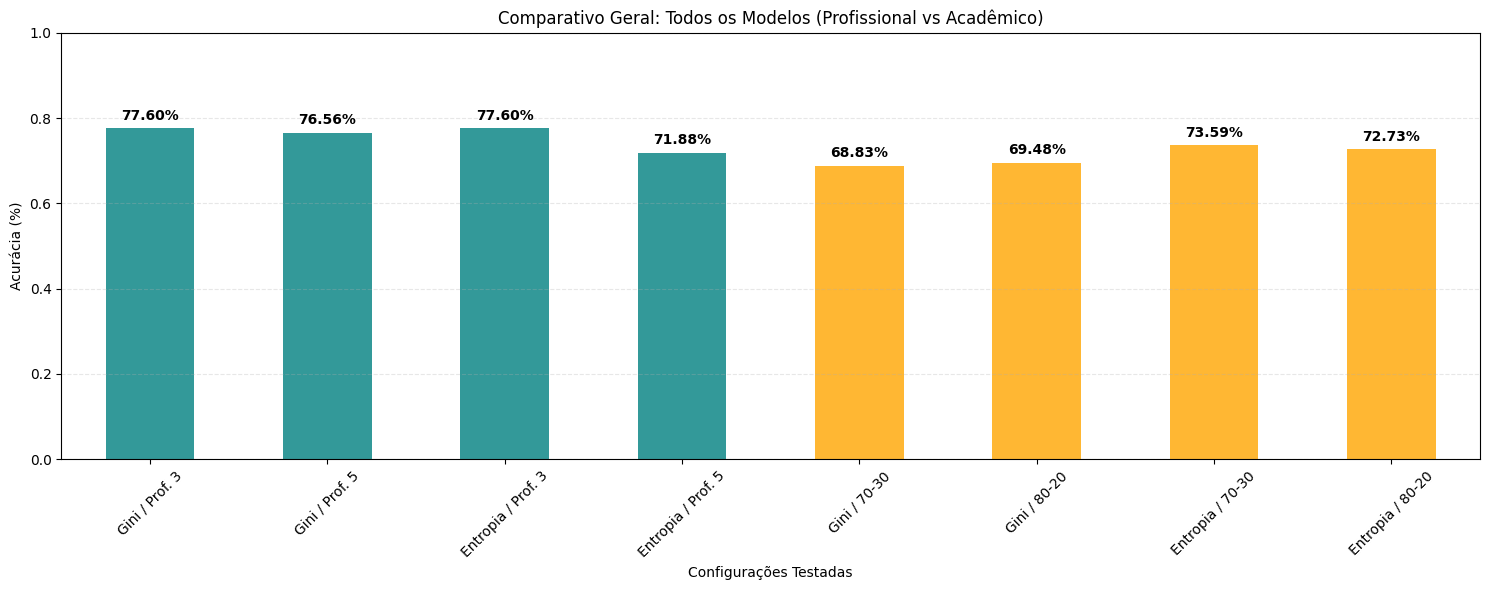

--------------------------------------------------
VENCEDOR GERAL: MODELO PROFISSIONAL (77.60%)


In [9]:
from diabetes import plotar_duelo_geral

# Gera o gráfico com todas as barras lado a lado
plotar_duelo_geral(df_res_prof, df_res_acad)

# Mantém a sua lógica de explicação abaixo
melhor_prof = df_res_prof['Acurácia'].max()
melhor_acad = df_res_acad['Acurácia'].max()

print("-" * 50)
if melhor_prof >= melhor_acad:
    print(f"VENCEDOR GERAL: MODELO PROFISSIONAL ({melhor_prof:.2%})")
else:
    print(f"VENCEDOR GERAL: MODELO ACADÊMICO ({melhor_acad:.2%})")


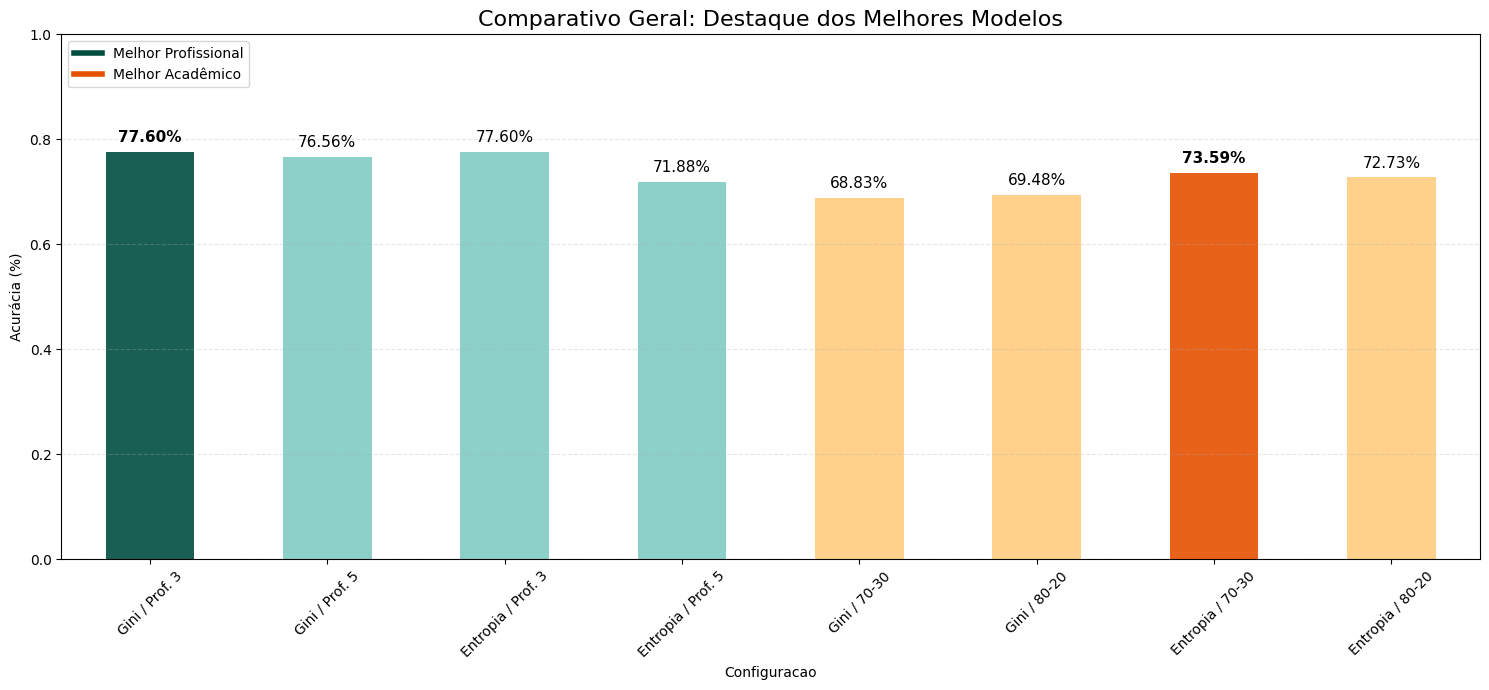

In [10]:
# Executa o comparativo com os destaques coloridos
plotar_duelo_geral_destacado(df_res_prof, df_res_acad)


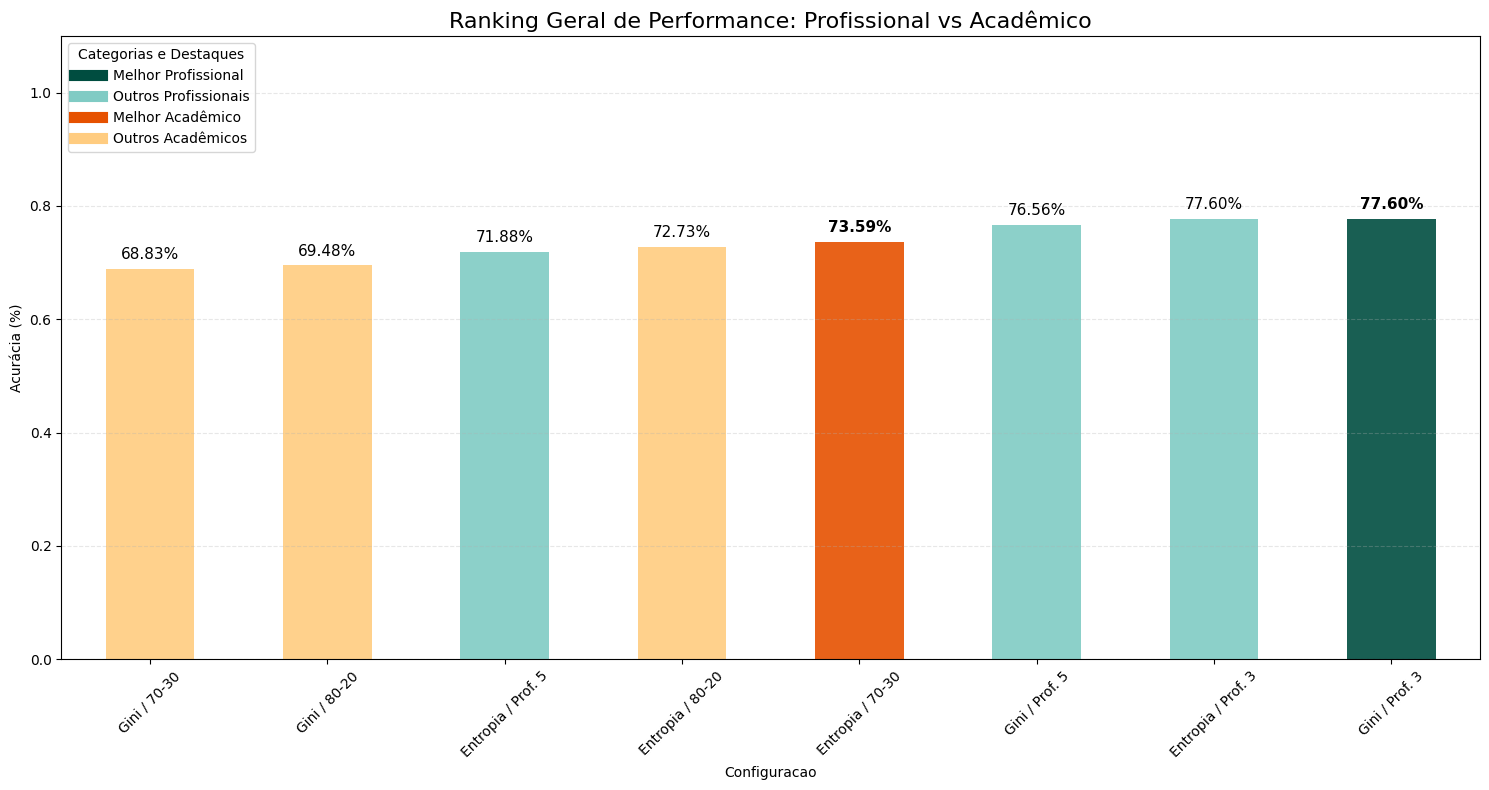

In [11]:
plotar_duelo_geral_ordenado(df_res_prof, df_res_acad)


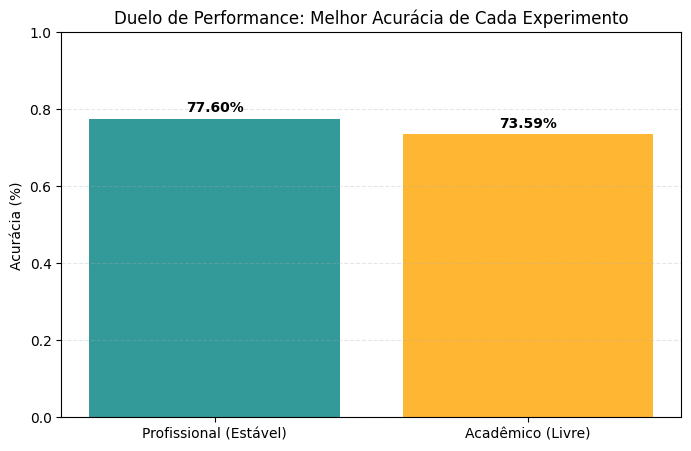

VENCEDOR: MODELO PROFISSIONAL (77.60%)
MOTIVO: Melhor equilíbrio entre simplicidade e assertividade.


In [12]:


# 1. Busca os valores
melhor_prof = df_res_prof['Acurácia'].max()
melhor_acad = df_res_acad['Acurácia'].max()

# 2. Mostra o Gráfico
plotar_comparativo_final(melhor_prof, melhor_acad)

# 3. Mostra a Explicação (O seu código de texto)
if melhor_prof >= melhor_acad:
    print(f"VENCEDOR: MODELO PROFISSIONAL ({melhor_prof:.2%})")
    print("MOTIVO: Melhor equilíbrio entre simplicidade e assertividade.")
else:
    print(f"VENCEDOR: MODELO ACADÊMICO ({melhor_acad:.2%})")
    print("MOTIVO: Maior exploração dos dados, porém com risco de 'decorar' o treino.")


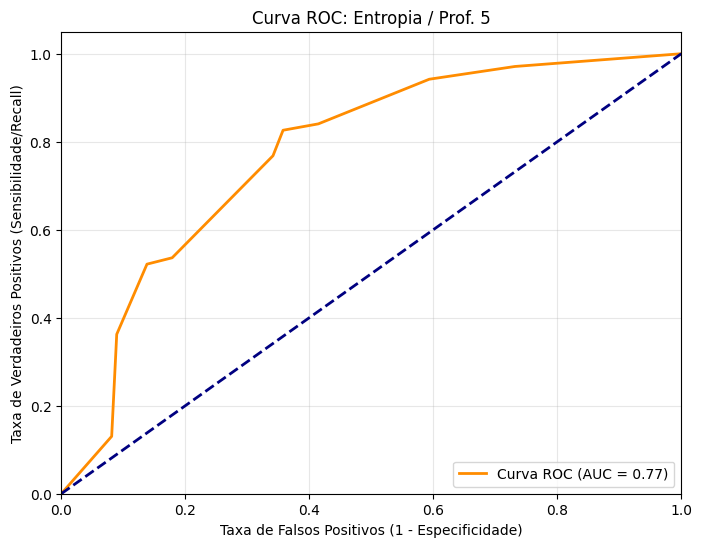

In [13]:
# Usando os dados que já estão no seu df_res_prof
config_nome = df_res_prof.index[-1]
modelo = df_res_prof.loc[config_nome, 'modelo']
X_teste = df_res_prof.loc[config_nome, 'X_teste'] # Certifique-se que o df_res guarda o X_teste
y_real = df_res_prof.loc[config_nome, 'y_real']

# Chamada da Curva ROC
plotar_curva_roc(modelo, X_teste, y_real, config_nome)


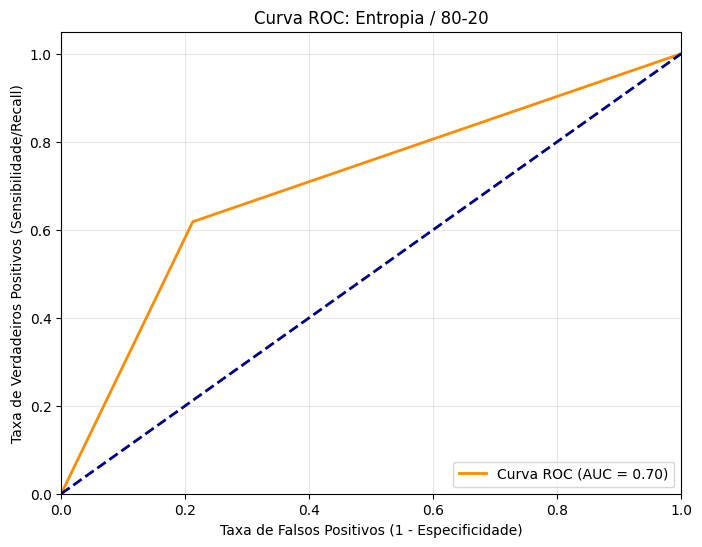

In [14]:
# Versão para o ACADÊMICO
config_nome = df_res_acad.index[-1]
modelo = df_res_acad.loc[config_nome, 'modelo']
X_teste = df_res_acad.loc[config_nome, 'X_teste']
y_real = df_res_acad.loc[config_nome, 'y_real']

plotar_curva_roc(modelo, X_teste, y_real, config_nome)


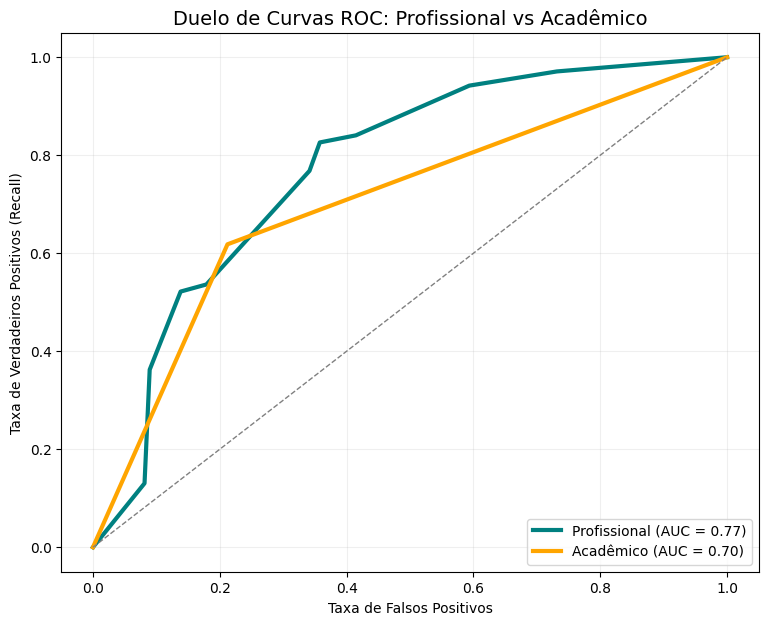

In [15]:
from diabetes import plotar_comparativo_roc

# Pega dados do Profissional
mod_p = df_res_prof.iloc[-1]['modelo']
X_p, y_p = df_res_prof.iloc[-1]['X_teste'], df_res_prof.iloc[-1]['y_real']

# Pega dados do Acadêmico
mod_a = df_res_acad.iloc[-1]['modelo']
X_a, y_a = df_res_acad.iloc[-1]['X_teste'], df_res_acad.iloc[-1]['y_real']

# Gera o gráfico comparativo
plotar_comparativo_roc(mod_p, X_p, y_p, mod_a, X_a, y_a)


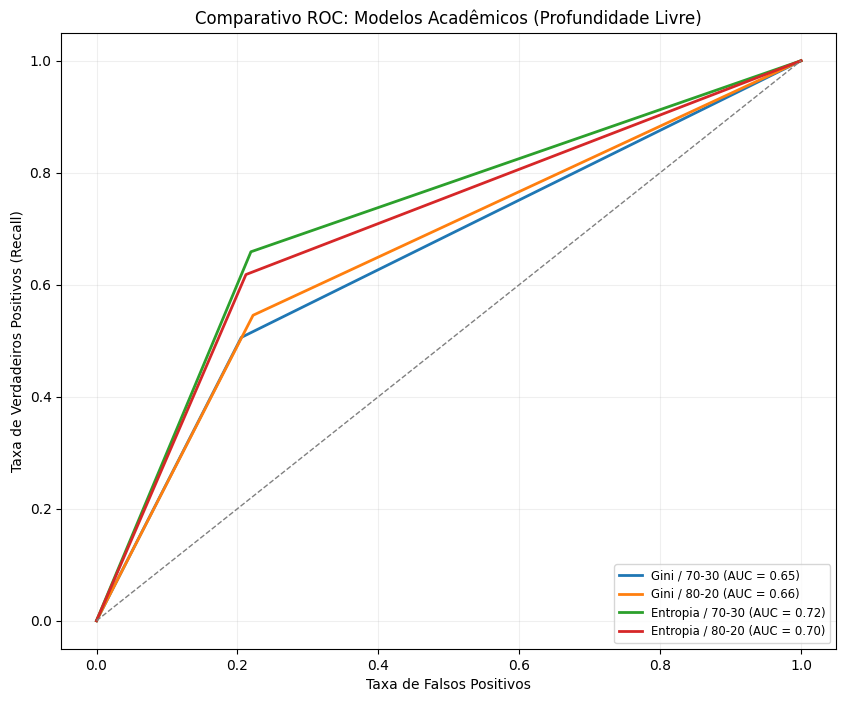

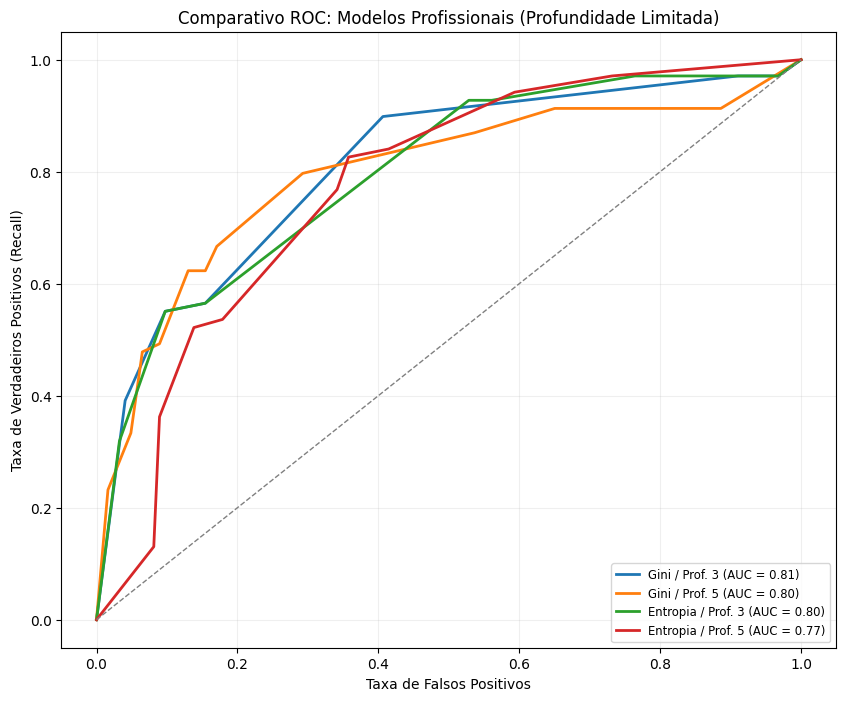

In [16]:
from diabetes import plotar_roc_multiplos

# Plota todos os acadêmicos
plotar_roc_multiplos(df_res_acad, "Modelos Acadêmicos (Profundidade Livre)")

# Plota todos os profissionais (se quiser comparar também)
plotar_roc_multiplos(df_res_prof, "Modelos Profissionais (Profundidade Limitada)")
